# CIFAR-10 CNN

In [1]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import keras
from keras import layers
from tensorflow.keras.datasets import cifar10

import numpy as np
import matplotlib.pyplot as plt

from keras import backend as K
print(K.backend())

C:\Users\Omistaja\anaconda3\envs\keras\Lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


tensorflow


In [30]:
from tensorflow.keras.utils import to_categorical
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

x_train, x_test = x_train / 255, x_test / 255
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

print(x_train.shape)
print(y_train.shape)

(50000, 32, 32, 3, 1)
(50000, 10)


## Building the model
I tried using BatchNormalization to optimize the model, but it only decreased results

In [37]:
from keras.layers import Input, Flatten, Dense, BatchNormalization
from keras import models

inputs = keras.Input(shape=(32, 32, 3))
x = keras.layers.Conv2D(32, kernel_size=(3, 3), activation='relu')(inputs)
x = keras.layers.MaxPooling2D(pool_size=(2, 2))(x)
x = keras.layers.Conv2D(64, kernel_size=(3, 3), activation='relu')(x)
x = keras.layers.MaxPooling2D(pool_size=(2, 2))(x)
x = layers.Flatten()(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(10, activation="softmax")(x)

model = keras.Model(inputs=inputs, outputs=outputs, name="mnist_model")

In [38]:
model.compile(
    loss="categorical_crossentropy",
    optimizer=keras.optimizers.Adam(),
    metrics=["accuracy"],
)

In [39]:
history = model.fit(x_train, y_train, batch_size=32, epochs=10, validation_split=0.2)

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.4272 - loss: 1.5934 - val_accuracy: 0.5419 - val_loss: 1.3140
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5378 - loss: 1.3029 - val_accuracy: 0.5771 - val_loss: 1.2272
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5776 - loss: 1.2015 - val_accuracy: 0.6116 - val_loss: 1.1341
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6022 - loss: 1.1391 - val_accuracy: 0.6262 - val_loss: 1.0803
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6163 - loss: 1.0957 - val_accuracy: 0.6349 - val_loss: 1.0565
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6304 - loss: 1.0598 - val_accuracy: 0.6674 - val_loss: 0.9893
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6395 - loss: 1.0312 - val_accuracy: 0.6653 - val_loss: 0.9811
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6504 - loss: 1.0013 - 

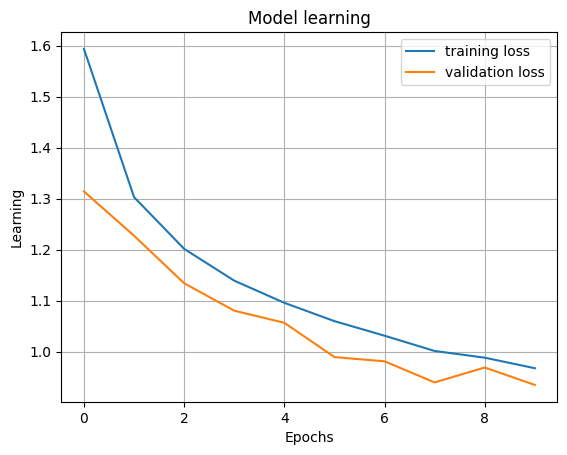

In [40]:
plt.plot(history.history["loss"], label="training loss")
plt.plot(history.history["val_loss"], label="validation loss")
plt.title("Model learning")
plt.xlabel('Epochs')
plt.ylabel('Learning')
plt.legend()
plt.grid()
plt.show()

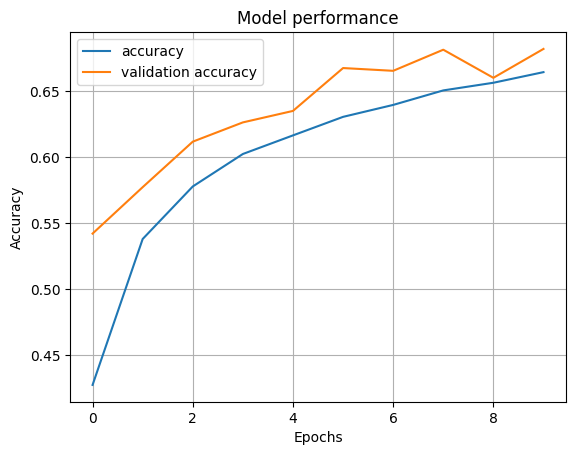

In [41]:
plt.plot(history.history["accuracy"], label="accuracy")
plt.plot(history.history["val_accuracy"], label="validation accuracy")
plt.title("Model performance")
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()

## Example images
![Raven image](img/raven.jpg) ✔ This picture depicts a raven and is correctly identified as a bird  

![Ostrich image](img/ostrich.jpg) ✔ This picture depicts an ostrich and is correctly labeled as a bird  

![Zebra image](img/zebra.jpg) ✔ This picture depicts a zebra and is correctly identified as a horse  

![Stealth jet image](img/stealth_jet.jpg) ✔ This picture depicts a stealth jet and is correctly identified as an airplane  

![Monster truck image](img/monster_truck.jpg) ✔ This picture depicts a monster truck and is correctly identified as a truck

In [20]:
# img preprocessing and loading from geeksforgeeks / ChatGPT.
from keras.preprocessing.image import load_img
from keras.preprocessing.image import img_to_array

def load_and_process_image(name):
    img = load_img(f'img/{name}')
    img_array = img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    return img_array

In [43]:
class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

def predict_image(img_array, name):
    predictions = model.predict(img_array, verbose=0)
    predicted_index = np.argmax(predictions[0])
    predicted_label = class_names[predicted_index]
    print(f"Image {name} is predicted to be {predicted_label}")
    return predictions[0]

In [44]:
probs1 = predict_image(load_and_process_image('raven.jpg'), 'Raven')
probs2 = predict_image(load_and_process_image('ostrich.jpg'), 'Ostrich')
probs3 = predict_image(load_and_process_image('zebra.jpg'), 'Zebra')
probs4 = predict_image(load_and_process_image('stealth_jet.jpg'), 'Stealth Jet')
probs5 = predict_image(load_and_process_image('monster_truck.jpg'), 'Monster Truck')

Image Raven is predicted to be bird
Image Ostrich is predicted to be bird
Image Zebra is predicted to be deer
Image Stealth Jet is predicted to be airplane
Image Monster Truck is predicted to be truck


### Probability distributions per image

C:\Users\Omistaja\AppData\Local\Temp\ipykernel_26944\1195392716.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(class_names, rotation=45)
C:\Users\Omistaja\AppData\Local\Temp\ipykernel_26944\1195392716.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(class_names, rotation=45)
C:\Users\Omistaja\AppData\Local\Temp\ipykernel_26944\1195392716.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(class_names, rotation=45)
C:\Users\Omistaja\AppData\Local\Temp\ipykernel_26944\1195392716.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(class_names, rotation=45)
C:\Users\Omistaj

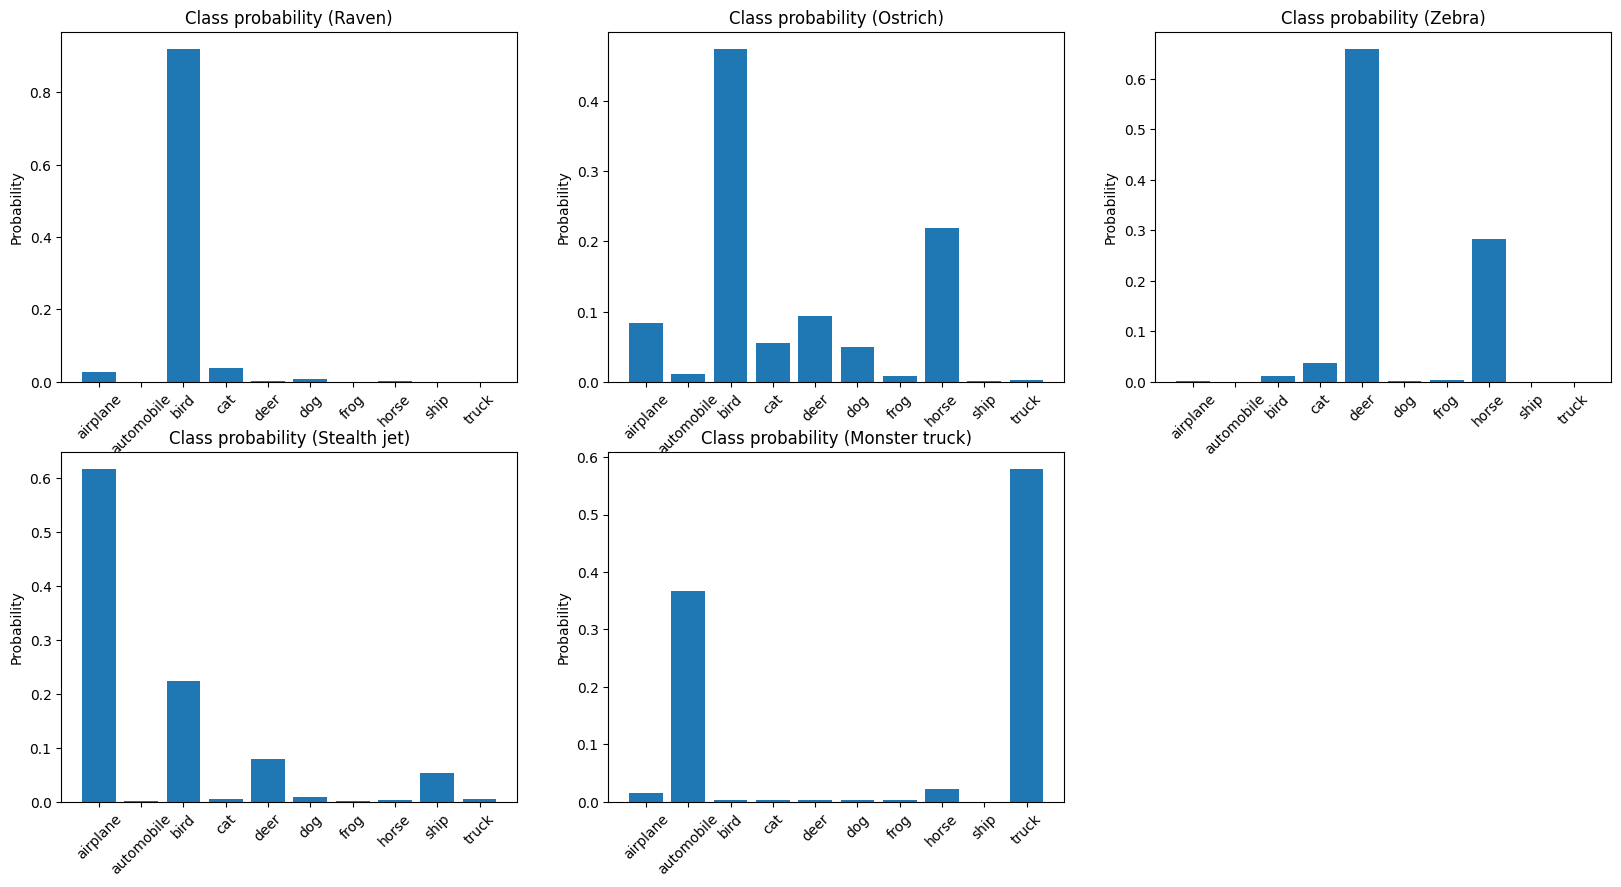

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [46]:
import math
all_probs = [probs1, probs2, probs3, probs4, probs5]
all_names = ["Raven", "Ostrich", "Zebra", "Stealth jet", "Monster truck"]

n_items = len(all_probs)
n_cols = 3
n_rows = math.ceil(n_items / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()

for i, probs in enumerate(all_probs):
    plt.figure()
    ax = axes[i]
    ax.bar(class_names, probs)
    ax.set_xticklabels(class_names, rotation=45)
    ax.set_ylabel("Probability")
    ax.set_title(f"Class probability ({all_names[i]})")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()